# Experiment 1: rotation invariance of kernel ESS on S²


This notebook reproduces Experiment 1 from the paper: the rotation-invariance demonstration on the sphere.

Set `RUN_FULL_EXPERIMENT = True` to use the manuscript settings.  The default `False` setting runs a much smaller version for a quick check.


In [1]:

# Choose whether to run the full manuscript experiment or a simplified quick version.
RUN_FULL_EXPERIMENT = False

# Re-run the simulation even if output files already exist.
# Set this to False to only reload existing outputs.
RERUN_SIMULATION = True

# Save figures in these formats.
FIGURE_FORMATS = ("png", "pdf")


In [2]:

from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "src.py").exists() and (ROOT.parent / "src.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import src

mode = "full" if RUN_FULL_EXPERIMENT else "quick"
outdir = ROOT / "outputs" / f"exp1_{mode}"
figdir = ROOT / "figures" / f"exp1_{mode}"
outdir.mkdir(parents=True, exist_ok=True)
figdir.mkdir(parents=True, exist_ok=True)
print(f"Repository root: {ROOT}")
print(f"Output directory: {outdir}")


Repository root: /mnt/data/IntrinsicESS_publication
Output directory: /mnt/data/IntrinsicESS_publication/outputs/exp1_quick



## Experiment settings

The full settings match the manuscript: 1000 burn-in iterations, 3000 retained draws, and 80 random rotations.


In [3]:

if RUN_FULL_EXPERIMENT:
    settings = dict(
        seed=20260201,
        burn=1000,
        n_keep=3000,
        n_rot=80,
        rho=0.75,
        target_kappa=12.0,
        proposal_kappa=35.0,
        save_chain=True,
    )
else:
    settings = dict(
        seed=20260201,
        burn=200,
        n_keep=600,
        n_rot=12,
        rho=0.75,
        target_kappa=12.0,
        proposal_kappa=35.0,
        save_chain=True,
    )
settings


{'seed': 20260201,
 'burn': 200,
 'n_keep': 600,
 'n_rot': 12,
 'rho': 0.75,
 'target_kappa': 12.0,
 'proposal_kappa': 35.0,
 'save_chain': True}


## Run or load the experiment


In [4]:

needed = [outdir / "exp1_rotation_ess.csv", outdir / "exp1_config_summary.json"]
if RERUN_SIMULATION or not all(p.exists() for p in needed):
    config = src.run_rotation_experiment(outdir=outdir, **settings)
else:
    config = src.load_json(outdir / "exp1_config_summary.json")
config


{'experiment': 'exp1_rotation_invariance',
 'seed': 20260201,
 'burn': 200,
 'n_keep': 600,
 'n_rot': 12,
 'rho': 0.75,
 'target_kappa': 12.0,
 'proposal_kappa': 35.0,
 'accept_rate': 0.73625,
 'base_kernel_ess': 123.77834782155858,
 'base_kernel_gamma0': 1.7245438453995696,
 'base_kernel_sigma2': 8.359509764433312,
 'base_kernel_bandwidth': 10}


## Summary table


In [5]:

summary_df, long_df, config = src.summarize_rotation_experiment(outdir)
summary_df.round(4)


,Quantity,Mean,SD,Min,Max,Range/mean
0,"Coordinate ESS, pooled axes",89.5476,3.2779,84.1385,94.9275,0.1205
1,"Coordinate ESS, axis 1",89.6494,3.5135,85.1101,94.9275,0.1095
2,"Coordinate ESS, axis 2",89.8814,3.3330,84.1385,93.6136,0.1054
3,"Coordinate ESS, axis 3",89.1121,3.2240,84.7111,93.9847,0.1041
4,Intrinsic kernel ESS,123.7783,0.0000,123.7783,123.7783,0.0000



## Figure

The intrinsic kernel ESS is unchanged under rotation because the kernel depends only on inner products.  Coordinate-wise ESS changes because the coordinate projections change.


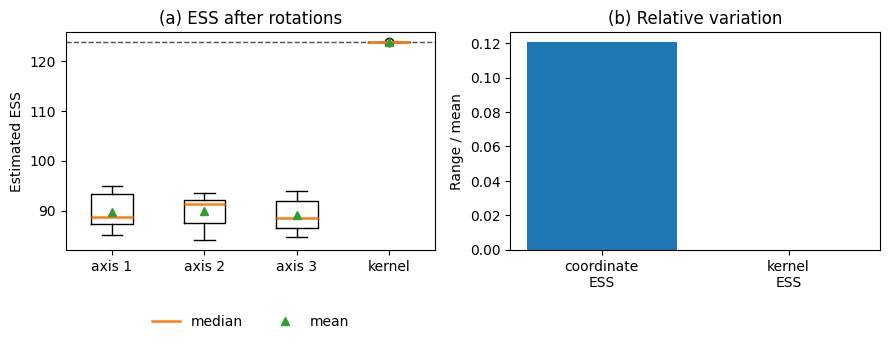

Saved figure to /mnt/data/IntrinsicESS_publication/figures/exp1_quick


In [6]:

src.plot_rotation_experiment(outdir, figdir, formats=FIGURE_FORMATS)
fig_path = figdir / "fig1.png"
display(Image(filename=str(fig_path)))
print(f"Saved figure to {figdir}")



## Output files


In [7]:

for p in sorted(outdir.glob("*")):
    print(p.relative_to(ROOT))
for p in sorted(figdir.glob("fig1.*")):
    print(p.relative_to(ROOT))


outputs/exp1_quick/exp1_chain.npz
outputs/exp1_quick/exp1_config_summary.json
outputs/exp1_quick/exp1_rotation_ess.csv
figures/exp1_quick/fig1.pdf
figures/exp1_quick/fig1.png
